# DS 5111 / DS 2508 – UNIQUE_SYMS dbt Model Report

**Student:** Chelsey Blowe  
**UVA ID:** qck2qg  
**Date:** 2025-12-02


## Data Collection and Table Locations

For this project, I collected stock “gainers” data from Yahoo Finance and the Wall Street Journal.  
The raw scraped CSV files were uploaded to Snowflake where each one became a table.

All project tables live in:

- **Database:** `DS2508`
- **Schema:** `QCK2QG`

Each CSV upload becomes a timestamped table such as:
- `YGAINERS_20251023_160116`
- `WSJGGAINERS_20251024_093108`
- `YGAINERS_20251027_093118`

I also created normalized tables that clean and standardize the raw data:

- `DS2508.QCK2QG.YGAINERS_NORMALIZED`
- `DS2508.QCK2QG.WSJGAINERS_NORMALIZED`

In total, there are approximately **43** Snowflake tables in this dataset  
(raw timestamped tables + normalized tables).

The dbt model `unique_syms` uses the two normalized tables as its inputs.


## Simple ERD for the UNIQUE_SYMS Model

The `unique_syms` model extracts ticker symbols from both normalized tables and produces a  
single table of all unique symbols.M

```text
DS2508.QCK2QG.YGAINERS_NORMALIZED      DS2508.QCK2QG.WSJGAINERS_NORMALIZED
                \                                   /
                 \                                 /
                  \                               /
                   \                             /
                    \                           /
                     v                         v
                      DS2508.QCK2QG.UNIQUE_SYMS
```


## (c) GitHub Link and Model SQL

**GitHub link to the dbt model:**

`https://github.com/ChelseyB-UVA/2508_DS5111_qck2qg/blob/mo10_dbt_model/models/example/unique_syms.sql`

**SQL that generates the `UNIQUE_SYMS` table (`models/example/unique_syms.sql`):**

```sql
{{ config(materialized='table') }}

SELECT DISTINCT SYMBOL
FROM (
    SELECT SYMBOL FROM {{ ref('ygainers_normalized') }}
    UNION ALL
    SELECT SYMBOL FROM {{ ref('wsjgainers_normalized') }}
)
WHERE SYMBOL IS NOT NULL
```


In [16]:
import pandas as pd

df = pd.read_csv("unique_syms.csv")

print("Shape:", df.shape)
df.head(10)


Shape: (190, 1)


,SYMBOL
0,FIGR
1,BIDU
2,IONQ
3,RIOT
4,TMC
5,CHA
6,PRCT
7,YPF
8,QBTS
9,VIST


## (g) Histogram of Symbol Counts

This histogram shows the distribution of how frequently each symbol appears
across all normalized gainers datasets.


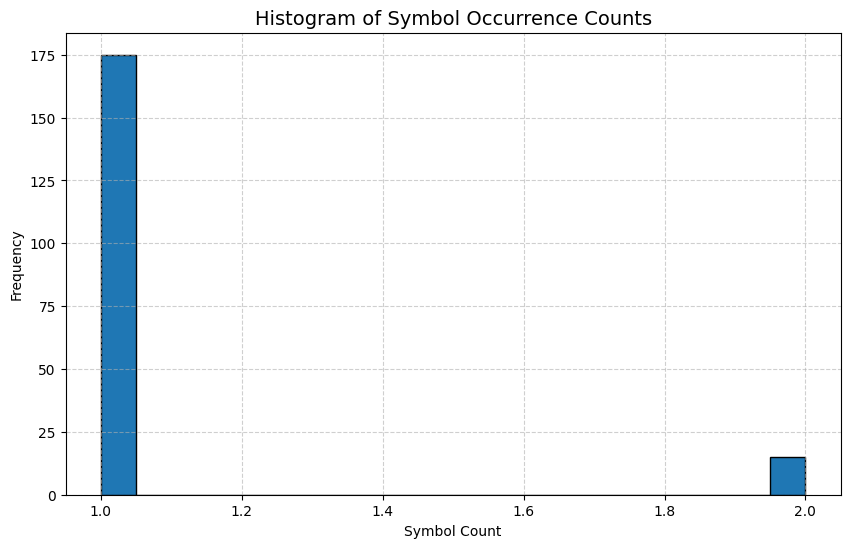

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

df_counts = pd.read_csv("unique_sym_counts.csv")

plt.figure(figsize=(10,6))
plt.hist(df_counts["SYMBOL_COUNT"], bins=20, edgecolor="black")
plt.title("Histogram of Symbol Occurrence Counts", fontsize=14)
plt.xlabel("Symbol Count")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()


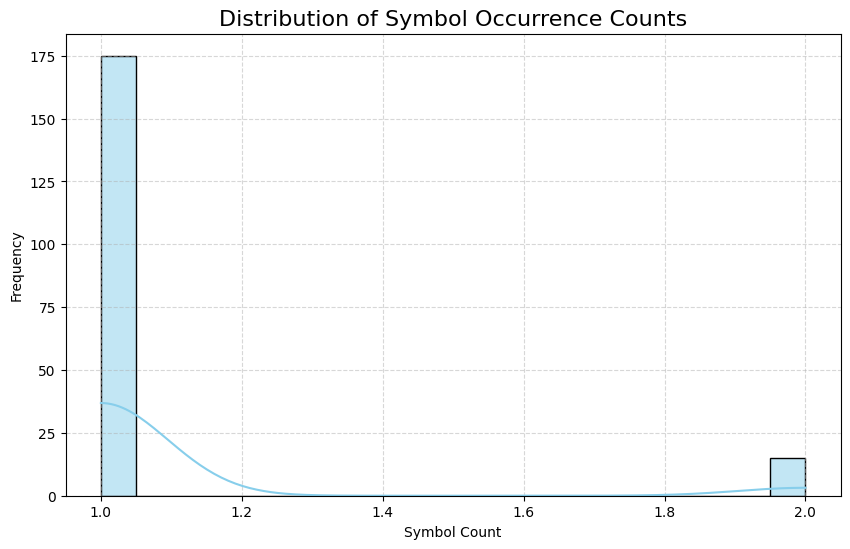

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_counts = pd.read_csv("unique_sym_counts.csv")

plt.figure(figsize=(10,6))
sns.histplot(df_counts["SYMBOL_COUNT"], bins=20, kde=True, color="skyblue", edgecolor="black")
plt.title("Distribution of Symbol Occurrence Counts", fontsize=16)
plt.xlabel("Symbol Count")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


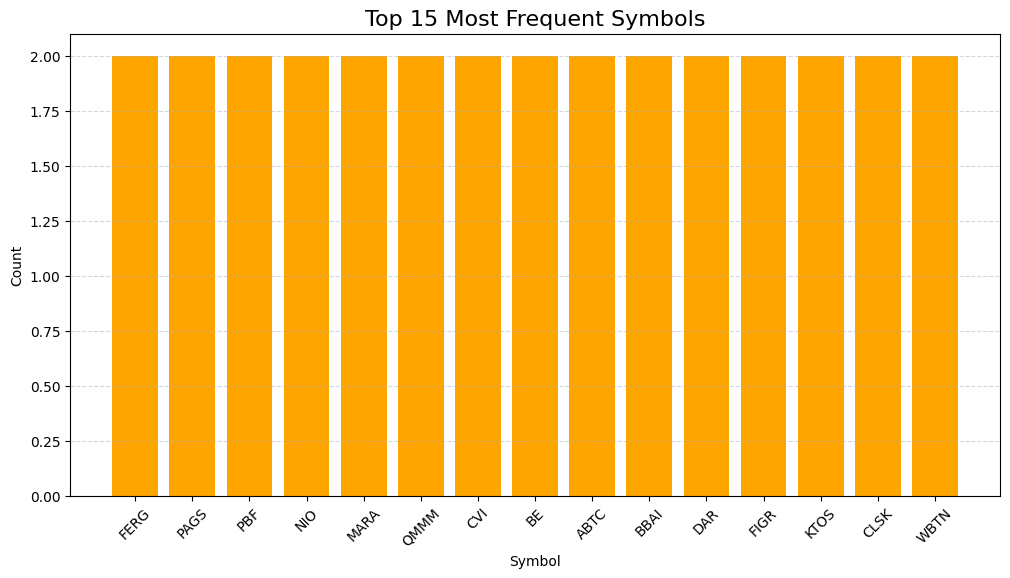

In [29]:
top15 = df_counts.sort_values("SYMBOL_COUNT", ascending=False).head(15)

plt.figure(figsize=(12,6))
plt.bar(top15["SYMBOL"], top15["SYMBOL_COUNT"], color="orange")
plt.title("Top 15 Most Frequent Symbols", fontsize=16)
plt.xlabel("Symbol")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()


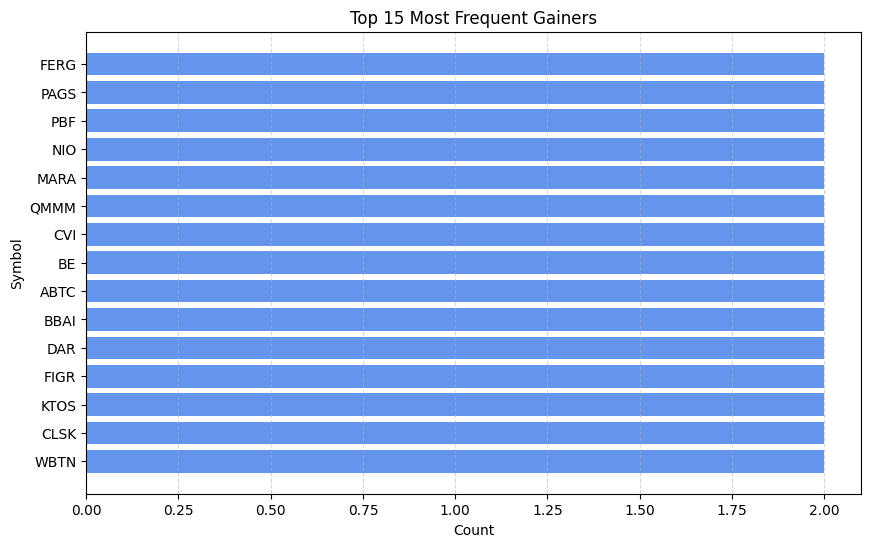

In [30]:
top15 = df_counts.sort_values("SYMBOL_COUNT", ascending=False).head(15)

plt.figure(figsize=(10,6))
plt.barh(top15["SYMBOL"], top15["SYMBOL_COUNT"], color="cornflowerblue")
plt.title("Top 15 Most Frequent Gainers")
plt.xlabel("Count")
plt.ylabel("Symbol")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.show()


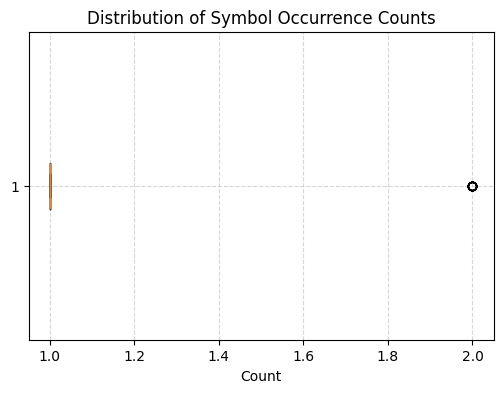

In [31]:
plt.figure(figsize=(6,4))
plt.boxplot(df_counts["SYMBOL_COUNT"], vert=False)
plt.title("Distribution of Symbol Occurrence Counts")
plt.xlabel("Count")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


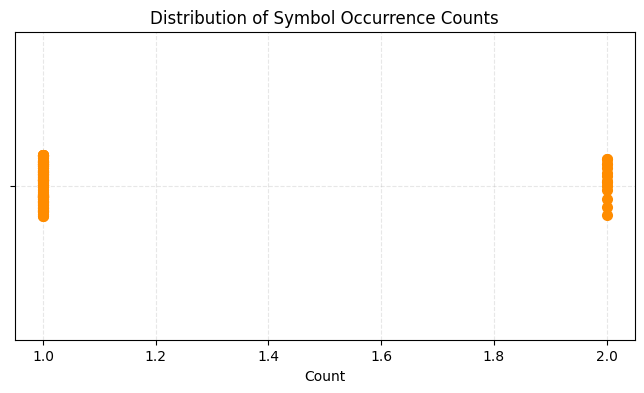

In [35]:
import seaborn as sns

plt.figure(figsize=(8,4))
sns.stripplot(x=df_counts["SYMBOL_COUNT"], size=8, color="darkorange")
plt.title("Distribution of Symbol Occurrence Counts")
plt.xlabel("Count")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()


In [38]:
lowest = df_counts[df_counts["SYMBOL_COUNT"] == df_counts["SYMBOL_COUNT"].min()]
highest = df_counts[df_counts["SYMBOL_COUNT"] == df_counts["SYMBOL_COUNT"].max()]

print("Lowest Frequency Symbols:")
display(lowest)

print("\nHighest Frequency Symbols:")
display(highest)


Lowest Frequency Symbols:


,SYMBOL,SYMBOL_COUNT
15,CHRD,1
16,BRBR,1
17,MGY,1
18,SKY,1
19,DRMA,1
...,...,...
185,SDRL,1
186,KLRS,1
187,AEI,1
188,APLM,1



Highest Frequency Symbols:


,SYMBOL,SYMBOL_COUNT
0,FERG,2
1,PAGS,2
2,PBF,2
3,NIO,2
4,MARA,2
5,QMMM,2
6,CVI,2
7,BE,2
8,ABTC,2
9,BBAI,2


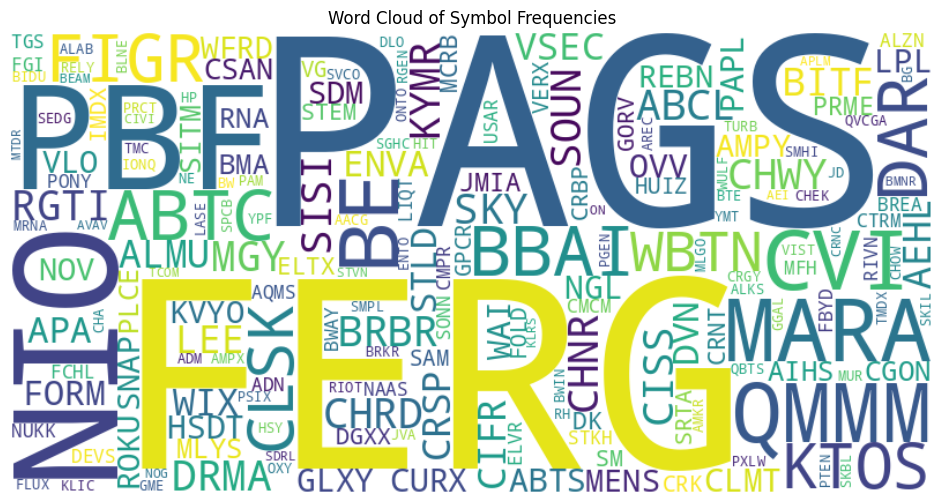

In [34]:
from wordcloud import WordCloud

symbol_dict = dict(zip(df_counts["SYMBOL"], df_counts["SYMBOL_COUNT"]))

wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(symbol_dict)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Symbol Frequencies")
plt.show()
